In [1]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted


In [2]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/MLDM/Hana Alsaadi Dataset.zip"
extract_to = "/content/"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_to)
    print("Files extracted:")
    for f in z.namelist():
        print(f"  {f}")

Files extracted:
  Dataset Keys.pdf
  Digital marketing dataset.xlsx
  Questions of online questionnaire.pdf


In [3]:
import pandas as pd

df = pd.read_excel("/content/Digital marketing dataset.xlsx")
df.columns = df.columns.str.strip()

print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head(3)

Shape: (520, 49)
Missing values: 0


,Gender,Age,Education,Marital_status,Number_of_children,Location,Monthly_Income,Daily_H_Using _Phone,Monthly_Online_Shopping,Take_Glance,...,Repeated_Exposure,SM_Users_Recommendations,SM_Marketing_Campaigns,SM_Influencers_Recommendations,Shipping_Cost,Lack_Reviews,Unavailability_COD,Hard_Return_Service,Delivery_Time,DM_Impact
0,1,1,2,1,1,5,1,1,2,0,...,1,2,1,3,1,1,3,3,1,3
1,1,1,2,1,1,5,1,2,2,1,...,2,2,1,3,1,2,2,1,1,3
2,1,1,1,1,1,5,2,2,5,0,...,1,2,1,1,1,1,1,1,1,3


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.cluster         import KMeans
from sklearn.metrics         import (accuracy_score, classification_report,
                                     confusion_matrix, f1_score,
                                     precision_score, recall_score)
import warnings
warnings.filterwarnings("ignore")
print("✅ Libraries imported successfully")

✅ Libraries imported successfully


**Class distribution (Figure 1)**

DM_Impact
3    259
1    143
2    118
Name: count, dtype: int64


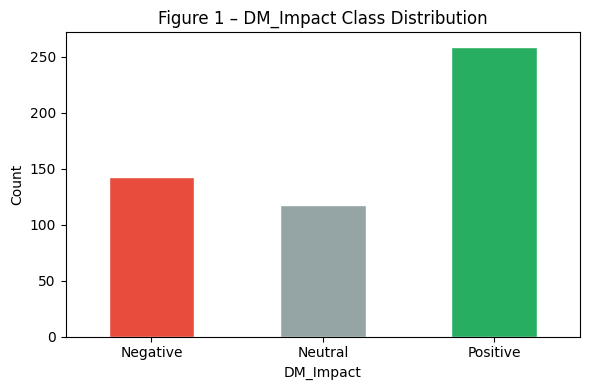

In [5]:
print(df["DM_Impact"].value_counts())

plt.figure(figsize=(6,4))
df["DM_Impact"].value_counts().sort_index().plot(
    kind="bar", color=["#E74C3C","#95A5A6","#27AE60"], edgecolor="white")
plt.xticks([0,1,2], ["Negative","Neutral","Positive"], rotation=0)
plt.title("Figure 1 – DM_Impact Class Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("fig1_class_distribution.png", dpi=150)
plt.show()

**Feature importance on all 48 features**

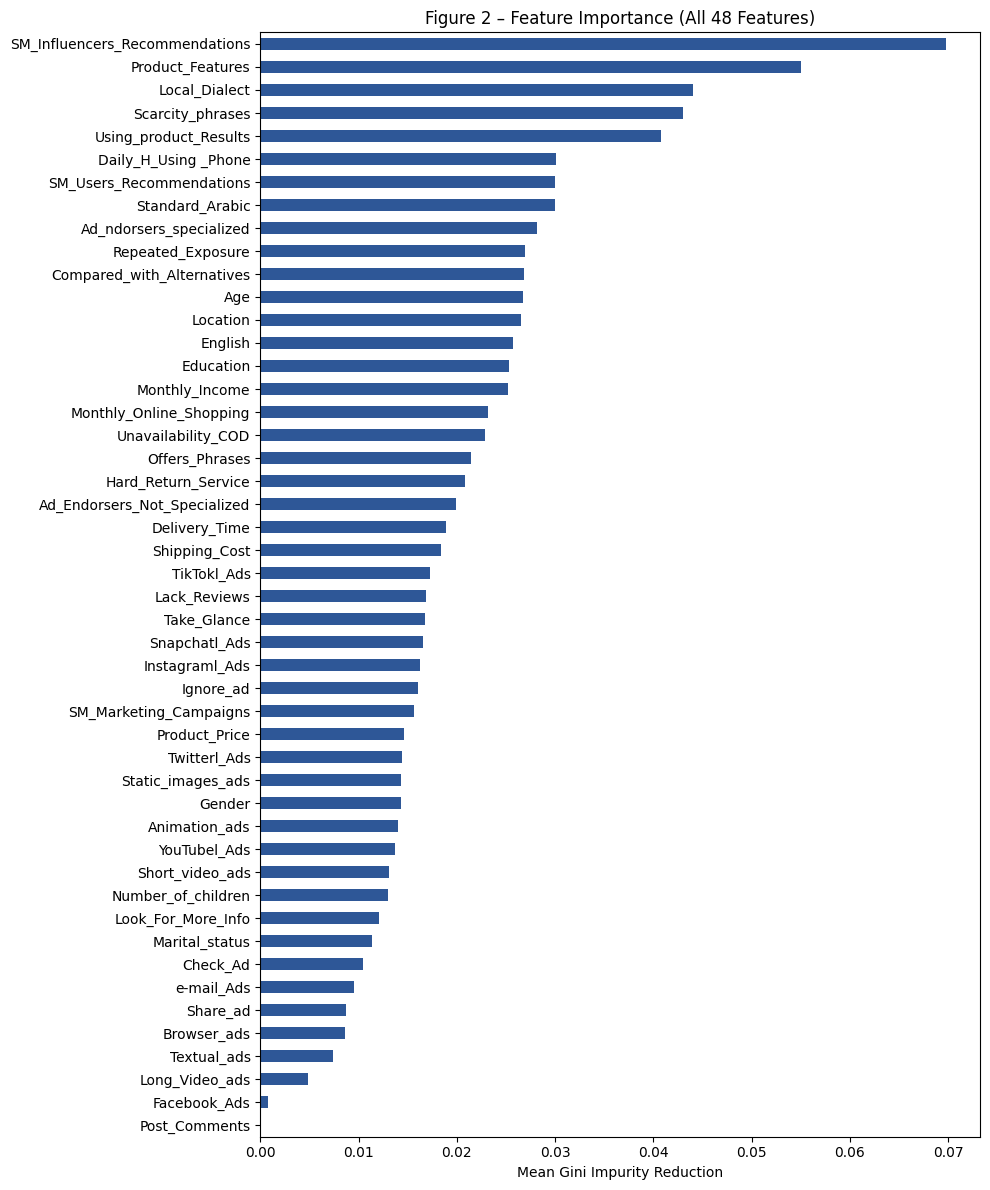


Top 7 features:
SM_Influencers_Recommendations    0.0697
Product_Features                  0.0550
Local_Dialect                     0.0440
Scarcity_phrases                  0.0430
Using_product_Results             0.0408
Daily_H_Using _Phone              0.0301
SM_Users_Recommendations          0.0300
dtype: float64


In [6]:
X_all = df.drop("DM_Impact", axis=1)
y     = df["DM_Impact"]

rf_explore = RandomForestClassifier(n_estimators=100, random_state=42)
rf_explore.fit(X_all, y)

imp_all = pd.Series(rf_explore.feature_importances_,
    index=X_all.columns).sort_values(ascending=True)

plt.figure(figsize=(10,12))
imp_all.plot(kind="barh", color="#2E5797")
plt.title("Figure 2 – Feature Importance (All 48 Features)")
plt.xlabel("Mean Gini Impurity Reduction")
plt.tight_layout()
plt.savefig("fig2_feature_importance_all.png", dpi=150)
plt.show()

print("\nTop 7 features:")
print(imp_all.tail(7).sort_values(ascending=False).round(4))

**Select 7 features + descriptive stats + heatmap (Figure 3)**

Descriptive Statistics (Table 3):
       SM_Influencers_Recommendations  Product_Features  Scarcity_phrases  \
count                          520.00            520.00            520.00   
mean                             2.00              2.38              1.92   
std                              0.89              0.80              0.90   
min                              1.00              1.00              1.00   
25%                              1.00              2.00              1.00   
50%                              2.00              3.00              2.00   
75%                              3.00              3.00              3.00   
max                              3.00              3.00              3.00   

       Using_product_Results  SM_Users_Recommendations  Repeated_Exposure  \
count                 520.00                    520.00             520.00   
mean                    2.30                      1.99               1.68   
std                     0.85             

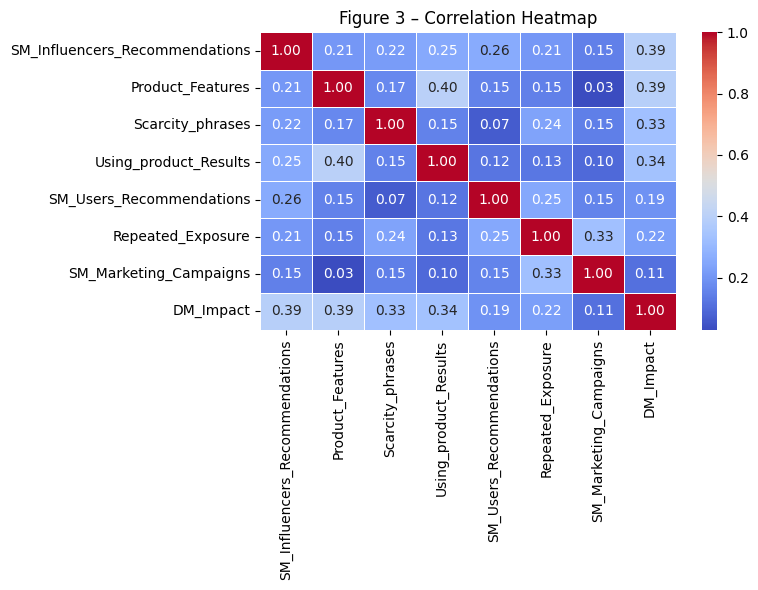

In [7]:
features = [
    "SM_Influencers_Recommendations",
    "Product_Features",
    "Scarcity_phrases",
    "Using_product_Results",
    "SM_Users_Recommendations",
    "Repeated_Exposure",
    "SM_Marketing_Campaigns"
]

X = df[features]
y = df["DM_Impact"]

print("Descriptive Statistics (Table 3):")
print(X.describe().round(2))

plt.figure(figsize=(8,6))
sns.heatmap(df[features + ["DM_Impact"]].corr(),
    annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Figure 3 – Correlation Heatmap")
plt.tight_layout()
plt.savefig("fig3_heatmap.png", dpi=150)
plt.show()

**Train-test split**

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training : {len(X_train)} samples")   # 416
print(f"Test     : {len(X_test)} samples")    # 104

Training : 416 samples
Test     : 104 samples


**Logistic Regression (Figure 6)**

In [9]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

print("═══ LOGISTIC REGRESSION ═══")
print(f"Accuracy : {accuracy_score(y_test, pred_lr):.4f}")
print(f"Macro F1 : {f1_score(y_test, pred_lr, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, pred_lr,
    target_names=["Negative","Neutral","Positive"]))

═══ LOGISTIC REGRESSION ═══
Accuracy : 0.5288
Macro F1 : 0.3915

Classification Report:
              precision    recall  f1-score   support

    Negative       0.47      0.55      0.51        29
     Neutral       0.00      0.00      0.00        25
    Positive       0.58      0.78      0.67        50

    accuracy                           0.53       104
   macro avg       0.35      0.44      0.39       104
weighted avg       0.41      0.53      0.46       104



**Decision Tree (Figure 7)**

In [10]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

print("═══ DECISION TREE ═══")
print(f"Accuracy : {accuracy_score(y_test, pred_dt):.4f}")
print(f"Macro F1 : {f1_score(y_test, pred_dt, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, pred_dt,
    target_names=["Negative","Neutral","Positive"]))

═══ DECISION TREE ═══
Accuracy : 0.5481
Macro F1 : 0.4822

Classification Report:
              precision    recall  f1-score   support

    Negative       0.48      0.45      0.46        29
     Neutral       0.46      0.24      0.32        25
    Positive       0.59      0.76      0.67        50

    accuracy                           0.55       104
   macro avg       0.51      0.48      0.48       104
weighted avg       0.53      0.55      0.53       104



**Random Forest default (Figure 8)**

═══ RANDOM FOREST (DEFAULT) ═══
Accuracy : 0.5192
Macro F1 : 0.4519

Classification Report:
              precision    recall  f1-score   support

    Negative       0.43      0.45      0.44        29
     Neutral       0.45      0.20      0.28        25
    Positive       0.57      0.72      0.64        50

    accuracy                           0.52       104
   macro avg       0.49      0.46      0.45       104
weighted avg       0.50      0.52      0.50       104



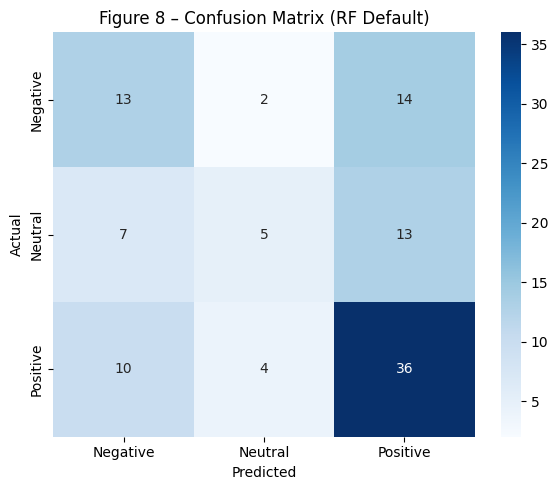

In [11]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("═══ RANDOM FOREST (DEFAULT) ═══")
print(f"Accuracy : {accuracy_score(y_test, pred_rf):.4f}")
print(f"Macro F1 : {f1_score(y_test, pred_rf, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, pred_rf,
    target_names=["Negative","Neutral","Positive"]))

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, pred_rf),
    annot=True, fmt="d", cmap="Blues",
    xticklabels=["Negative","Neutral","Positive"],
    yticklabels=["Negative","Neutral","Positive"])
plt.title("Figure 8 – Confusion Matrix (RF Default)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("fig8_cm_rf_default.png", dpi=150)
plt.show()

**GridSearchCV Hyperparameter Tuning (Figure 13)**

In [12]:
param_grid = {"n_estimators": [50, 100], "max_depth": [5, 10]}

grid = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42),
    param_grid = param_grid,
    cv         = 3,
    scoring    = "f1_macro",
    n_jobs     = -1
)
grid.fit(X_train, y_train)

print(f"Best parameters : {grid.best_params_}")
print(f"Best CV F1      : {grid.best_score_:.4f}")

Best parameters : {'max_depth': 5, 'n_estimators': 100}
Best CV F1      : 0.6037


**Optimized RF results (Figure 9 + 10 + 11)**

═══ RANDOM FOREST (OPTIMIZED) ═══
Accuracy  : 0.5481
Precision : 0.5627
Recall    : 0.4694
Macro F1  : 0.4589

Classification Report:
              precision    recall  f1-score   support

    Negative       0.43      0.45      0.44        29
     Neutral       0.67      0.16      0.26        25
    Positive       0.59      0.80      0.68        50

    accuracy                           0.55       104
   macro avg       0.56      0.47      0.46       104
weighted avg       0.56      0.55      0.51       104



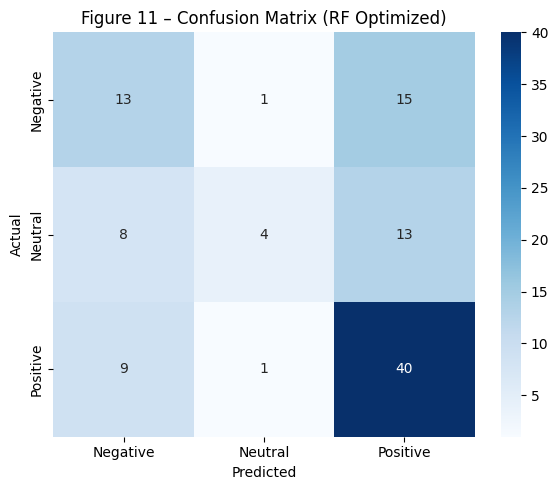

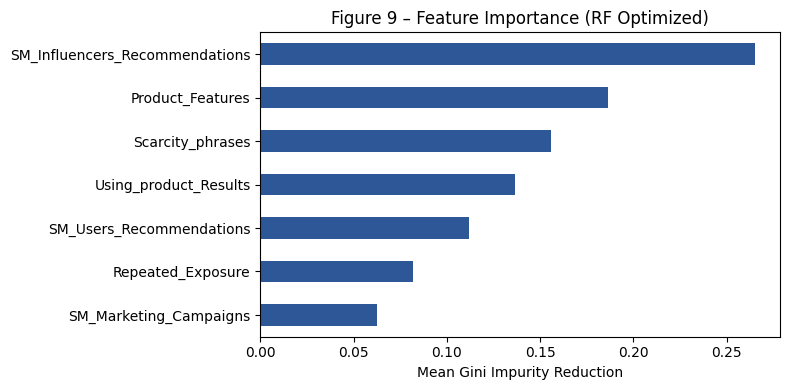

In [13]:
best_rf    = grid.best_estimator_
pred_best  = best_rf.predict(X_test)

print("═══ RANDOM FOREST (OPTIMIZED) ═══")
print(f"Accuracy  : {accuracy_score(y_test, pred_best):.4f}")
print(f"Precision : {precision_score(y_test, pred_best, average='macro'):.4f}")
print(f"Recall    : {recall_score(y_test, pred_best, average='macro'):.4f}")
print(f"Macro F1  : {f1_score(y_test, pred_best, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, pred_best,
    target_names=["Negative","Neutral","Positive"]))

# Confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, pred_best),
    annot=True, fmt="d", cmap="Blues",
    xticklabels=["Negative","Neutral","Positive"],
    yticklabels=["Negative","Neutral","Positive"])
plt.title("Figure 11 – Confusion Matrix (RF Optimized)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("fig11_cm_optimized.png", dpi=150)
plt.show()

# Feature importance
fi = pd.Series(best_rf.feature_importances_,
    index=features).sort_values(ascending=True)

plt.figure(figsize=(8,4))
fi.plot(kind="barh", color="#2E5797")
plt.title("Figure 9 – Feature Importance (RF Optimized)")
plt.xlabel("Mean Gini Impurity Reduction")
plt.tight_layout()
plt.savefig("fig9_feature_importance.png", dpi=150)
plt.show()

**Model comparison chart (Figure 12)**

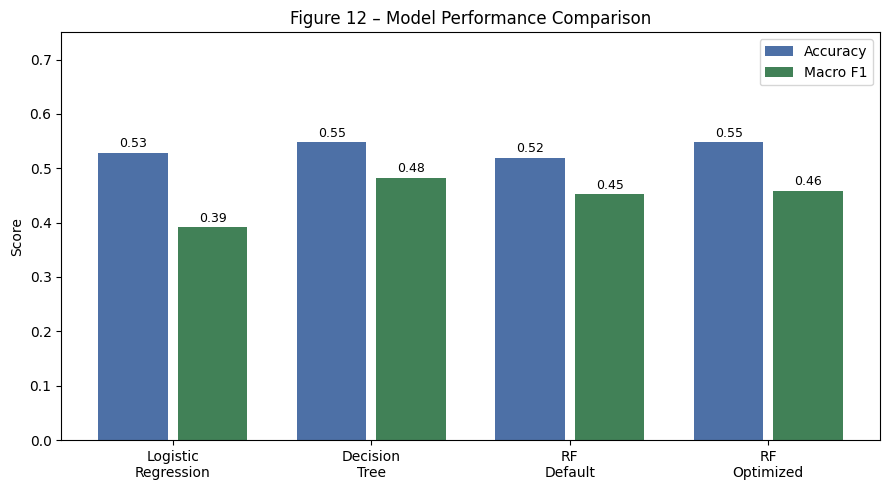

In [14]:
model_names = ["Logistic\nRegression","Decision\nTree",
               "RF\nDefault","RF\nOptimized"]
accuracies  = [accuracy_score(y_test, p)
               for p in [pred_lr, pred_dt, pred_rf, pred_best]]
f1_scores   = [f1_score(y_test, p, average="macro")
               for p in [pred_lr, pred_dt, pred_rf, pred_best]]

x = range(len(model_names))
plt.figure(figsize=(9,5))
plt.bar([i-0.2 for i in x], accuracies, width=0.35,
        label="Accuracy", color="#2E5797", alpha=0.85)
plt.bar([i+0.2 for i in x], f1_scores, width=0.35,
        label="Macro F1", color="#1F6B3A", alpha=0.85)
for i, (a, f) in enumerate(zip(accuracies, f1_scores)):
    plt.text(i-0.2, a+0.01, f"{a:.2f}", ha="center", fontsize=9)
    plt.text(i+0.2, f+0.01, f"{f:.2f}", ha="center", fontsize=9)
plt.xticks(list(x), model_names)
plt.ylim(0, 0.75)
plt.ylabel("Score")
plt.title("Figure 12 – Model Performance Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("fig12_model_comparison.png", dpi=150)
plt.show()

**K-Means clustering**

In [15]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)
df["Cluster"] = clusters

print("Cluster sizes:")
print(df["Cluster"].value_counts())

print("\nPurchase intention breakdown per cluster:")
for c in sorted(df["Cluster"].unique()):
    subset = df[df["Cluster"]==c]
    total  = len(subset)
    dist   = subset["DM_Impact"].value_counts()
    print(f"\nCluster {c} ({total} users):")
    for k, v in dist.items():
        label = {1:"Negative", 2:"Neutral", 3:"Positive"}[k]
        print(f"  {label}: {v} ({v/total*100:.0f}%)")

Cluster sizes:
Cluster
2    198
1    171
0    151
Name: count, dtype: int64

Purchase intention breakdown per cluster:

Cluster 0 (151 users):
  Negative: 82 (54%)
  Positive: 38 (25%)
  Neutral: 31 (21%)

Cluster 1 (171 users):
  Positive: 87 (51%)
  Negative: 44 (26%)
  Neutral: 40 (23%)

Cluster 2 (198 users):
  Positive: 134 (68%)
  Neutral: 47 (24%)
  Negative: 17 (9%)


**Cluster scatter plot (Figure 15)**

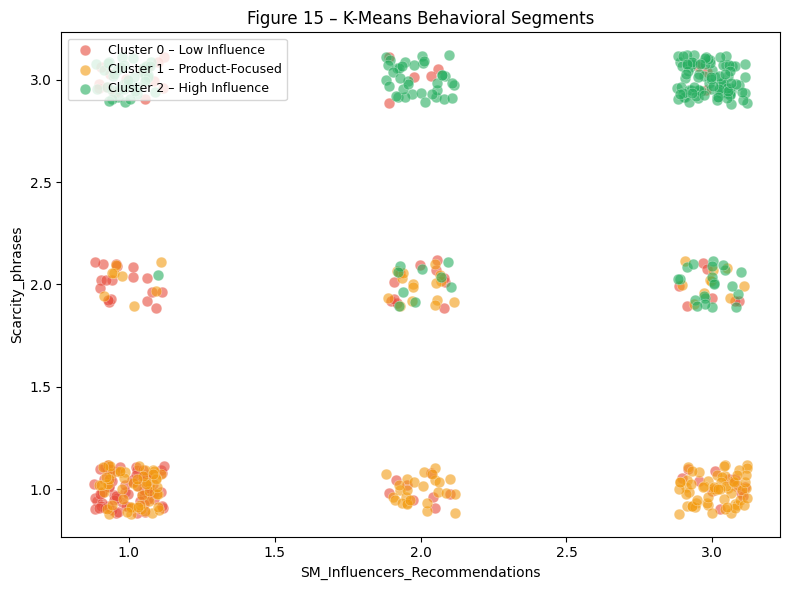

In [16]:
plt.figure(figsize=(8,6))

colors = {0:"#E74C3C", 1:"#F39C12", 2:"#27AE60"}
labels = {0:"Cluster 0 – Low Influence",
          1:"Cluster 1 – Product-Focused",
          2:"Cluster 2 – High Influence"}

for c in [0, 1, 2]:
    mask = clusters == c
    plt.scatter(
        df.loc[mask, "SM_Influencers_Recommendations"] + np.random.uniform(-0.12, 0.12, mask.sum()),
        df.loc[mask, "Scarcity_phrases"] + np.random.uniform(-0.12, 0.12, mask.sum()),
        c=colors[c], label=labels[c],
        alpha=0.6, edgecolors="white", linewidths=0.3, s=60)

plt.title("Figure 15 – K-Means Behavioral Segments")
plt.xlabel("SM_Influencers_Recommendations")
plt.ylabel("Scarcity_phrases")
plt.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("fig15_kmeans.png", dpi=150)
plt.show()

**Cluster centroid chart (Figure 16)**

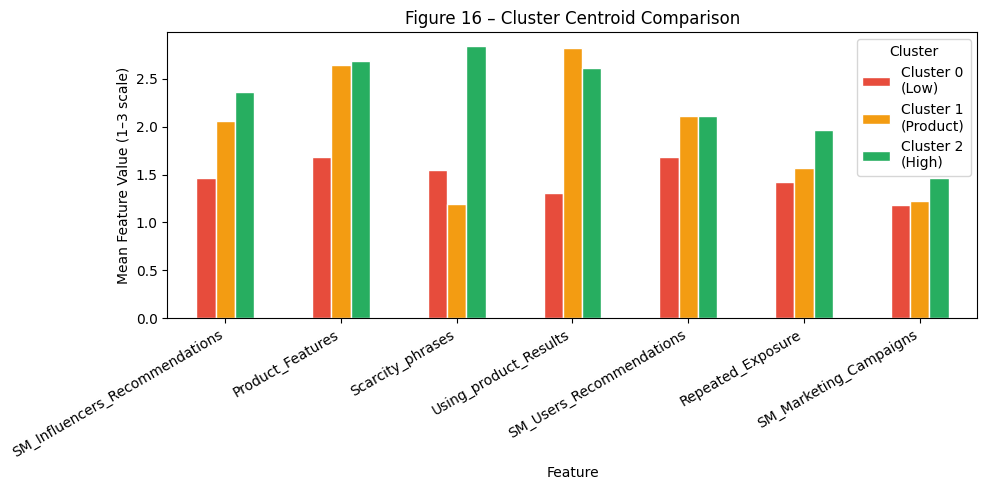

In [17]:
centroids = pd.DataFrame(kmeans.cluster_centers_,
    columns=features,
    index=["Cluster 0\n(Low)", "Cluster 1\n(Product)", "Cluster 2\n(High)"])

centroids.T.plot(kind="bar", figsize=(10,5),
    color=["#E74C3C","#F39C12","#27AE60"], edgecolor="white")
plt.title("Figure 16 – Cluster Centroid Comparison")
plt.ylabel("Mean Feature Value (1–3 scale)")
plt.xlabel("Feature")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Cluster")
plt.tight_layout()
plt.savefig("fig16_centroids.png", dpi=150)
plt.show()

**Download all saved figures**

In [18]:
from google.colab import files

figs = [
    "fig1_class_distribution.png",
    "fig2_feature_importance_all.png",
    "fig3_heatmap.png",
    "fig8_cm_rf_default.png",
    "fig9_feature_importance.png",
    "fig11_cm_optimized.png",
    "fig12_model_comparison.png",
    "fig15_kmeans.png",
    "fig16_centroids.png",
]

for f in figs:
    files.download(f)
    print(f"⬇ {f}")

print("\n✅ All done — insert figures into your report!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇ fig1_class_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

⬇ fig15_kmeans.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇ fig16_centroids.png

✅ All done — insert figures into your report!
